In [1]:
# This python notebook will create a CNN for predicting steering angles from a central dashcam in normal lighting conditions, then it will
# test the model under varying lighting conditions

# Then the notebook will create a CNN trained on varying lighting conditions and test the model under the same varying conditions

In [1]:
#Importing the required libraries
import os
print("OS Imported")
import numpy as np
print("Numpy Imported")
import pandas as pd
print("Pandas Imported")
import cv2
print("cv2 Imported")
import matplotlib.pyplot as plt
print("Matplotlib Imported")
from sklearn.model_selection import train_test_split
print("Sklearn Model Selection Imported")
from sklearn.metrics import mean_squared_error, r2_score
print("Sklearn metrics Imported")
from tensorflow.keras.models import Sequential
print("keras models Imported")
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Input
print("keras layers Imported")
from tensorflow.keras.optimizers import Adam
print("keras optimizers Imported")
from tensorflow.keras.callbacks import EarlyStopping
print("keras callbacks Imported")
import random
print("random Imported")
print("All libraries are successfully loaded")

OS Imported
Numpy Imported
Pandas Imported
cv2 Imported
Matplotlib Imported
Sklearn Model Selection Imported
Sklearn metrics Imported
keras models Imported
keras layers Imported
keras optimizers Imported
keras callbacks Imported
random Imported
All libraries are successfully loaded


In [2]:
# Currently the images that I am using are from https://www.kaggle.com/datasets/andy8744/udacity-self-driving-car-behavioural-cloning, I 
# used the road and not the jungle dataset.

# One problem with this approach is that the images were for windows files and I am using a macbook, hence i needed to re-write the image
# paths

# My file paths
datasetCsvPath = "/Users/redsparrow/Desktop/Coding/LumierePaper/driving_log.csv"
imgFolder = "/Users/redsparrow/Desktop/Coding/LumierePaper/IMG/"

# loading the dataset with custom column names
column = ['center', 'left', 'right', 'steeringAngle', 'throttle', 'reverse', 'speed']
df = pd.read_csv(datasetCsvPath, header=None, names=column)

def fixPath(x):
    x = x.replace("\\", "/")
    return os.path.join(imgFolder, os.path.basename(x))

df['center'] = df['center'].apply(fixPath)
df['left']   = df['left'].apply(fixPath)
df['right']  = df['right'].apply(fixPath)

In [14]:
# Defining the functions that I will use throughout this project

# loads the image useing opencv
def loadImage(path):
    img = cv2.imread(path)
    if img is None:
        print("FAILED:", path)
        return np.zeros((66,200,3))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (200, 66))
    img = img / 255.0
    return img

# This augment function simply reverses the angle and flips the image
def augmentImage(img, angle):
    if random.random() > 0.5:
        img = cv2.flip(img, 1)
        angle = -angle
    return img, angle

# This augment function reverses the angle, flips the image and changes the brightness
def augmentImageWithBrightness(img,angle,value):
    if random.random() > 0.5:
        img = cv2.flip(img, 1)
        angle = -angle
    if value >= 1:
        #bright lighting
        if random.random() > 0.5:
            img = brightenImage(img,value)
        
    elif value <= 1:
        # Dark lighting
        if random.random() > 0.5:
            img = darkenImage(img,value)
        
    return img, angle

# This augment function reverses the angle, flips the image and changes the brightness
def augmentImageWithBrightnessForTraining(img,angle):
    if random.random() > 0.5:
        img = cv2.flip(img, 1)
        angle = -angle
    choice = random.choice(['normal', 'bright', 'dark'])
    if choice == 'bright':
        img = brightenImage(img,1.6)
        
    elif choice == 'dark':
        img = darkenImage(img,0.4)
        
    return img, angle
    
# Generator batches images together
def generator(df, batch_size=32):
    while True:
        batchImages = []
        batchAngles = []
        df = df.sample(frac=1)  # shuffle
        for _, row in df.iterrows():
            # Choose randomly center/left/right
            choice = random.choice(['center', 'left', 'right'])
            angle = row['steeringAngle']
            correction = 0.25
            if choice == 'left':
                angle += correction
            elif choice == 'right':
                angle -= correction
            img = loadImage(row[choice])
            img, angle = augmentImage(img, angle)
            batchImages.append(img)
            batchAngles.append(angle)
            if len(batchImages) == batch_size:
                yield np.array(batchImages), np.array(batchAngles)
                batchImages, batchAngles = [], []

def generatorForBrightness(df,value,batch_size=32):
    while True:
        batchImages = []
        batchAngles = []
        df = df.sample(frac=1)  # shuffle
        for _, row in df.iterrows():
            # Choose randomly center/left/right
            choice = random.choice(['center', 'left', 'right'])
            angle = row['steeringAngle']
            correction = 0.25
            if choice == 'left':
                angle += correction
            elif choice == 'right':
                angle -= correction
            img = loadImage(row[choice])
            img, angle = augmentImageWithBrightness(img, angle, value)
            batchImages.append(img)
            batchAngles.append(angle)
            if len(batchImages) == batch_size:
                yield np.array(batchImages), np.array(batchAngles)
                batchImages, batchAngles = [], []

def trainingGeneratorForBrightness(df,batch_size=32):
    while True:
        batchImages = []
        batchAngles = []
        df = df.sample(frac=1)  # shuffle
        for _, row in df.iterrows():
            # Choose randomly center/left/right
            choice = random.choice(['center', 'left', 'right'])
            angle = row['steeringAngle']
            correction = 0.25
            if choice == 'left':
                angle += correction
            elif choice == 'right':
                angle -= correction
            img = loadImage(row[choice])
            img, angle = augmentImageWithBrightnessForTraining(img, angle)
            batchImages.append(img)
            batchAngles.append(angle)
            if len(batchImages) == batch_size:
                yield np.array(batchImages), np.array(batchAngles)
                batchImages, batchAngles = [], []

def brightenImage(img, factor=1.8):
    # remember original type/range
    type1 = np.issubdtype(img.dtype, np.floating)
    
    if type1:
        imgB = np.clip(img * 255.0, 0, 255).astype(np.uint8)
    else:
        imgB = img.copy()

    # convert to HSV, apply factor on V (value), convert back
    hsv = cv2.cvtColor(imgB, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[..., 2] = np.clip(hsv[..., 2] * factor, 0, 255)
    bright = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

    # return in same dtype/range as input
    if type1:
        return bright.astype(np.float32) / 255.0
    else:
        return bright

def darkenImage(img, factor=0.4):
    # remember original type/range
    type1 = np.issubdtype(img.dtype, np.floating)

    # convert to unit8 RGB for safe OpenCV color conversions
    if type1:
        imgD = np.clip(img * 255.0, 0, 255).astype(np.uint8)
    else:
        imgD = img.copy()

    hsv = cv2.cvtColor(imgD, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[..., 2] = np.clip(hsv[..., 2] * factor, 0, 255)
    dark = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)

    # return in same dtype/range as input
    if type1:
        return dark.astype(np.float32) / 255.0
    else:
        return dark

#number of departures - used for accuracy analysis
def laneDepart(yValReal,yPred):
    departures = 0
    for i in range(len(yValReal)):
        # Assumption 1 - if the predicted angle and actual angle are of different signs (predicts left when it has to turn right 
        # or vice versa) a lane departure has occured
        # multiply the numbers to check if the product is negative
        if(yValReal[i]*yPred[i]<0):
            departures += 1
        # Assumption 2 - if the predicted angle and actual angle have a difference greater than or equal to 0.1 (rad) 
        # then a lane departure has happened
        elif(abs(yValReal[i]-yPred[i])>=0.1):
            departures += 1
    # return the total number of departures found
    return departures

def dispTurnError(yValReal,yPred):
    departed = laneDepart(yValReal,yPred)
    # total turns
    print(f"The total amount of turns sampled in this dataset is: {len(yValReal)}")
    # wrong turns leading to lane departure
    print(f"The amount of lane departures caused by this model is: {departed}")
    # turn error rate % rounded to 2 decimal points
    print(f"Turn error rate: {round(departed*100/len(yValReal), 2)}%")

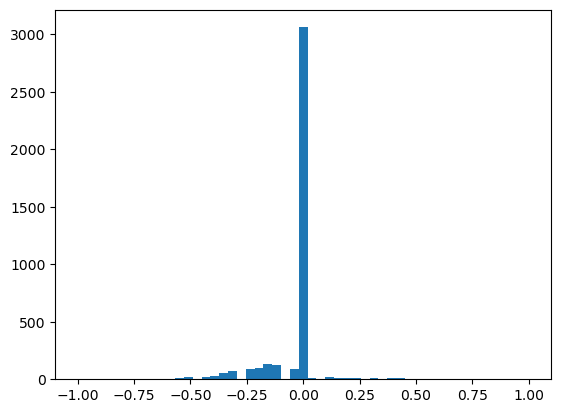

In [4]:
# Visualising the dataset's contained angles
plt.hist(df['steeringAngle'],bins = 51)
plt.show()

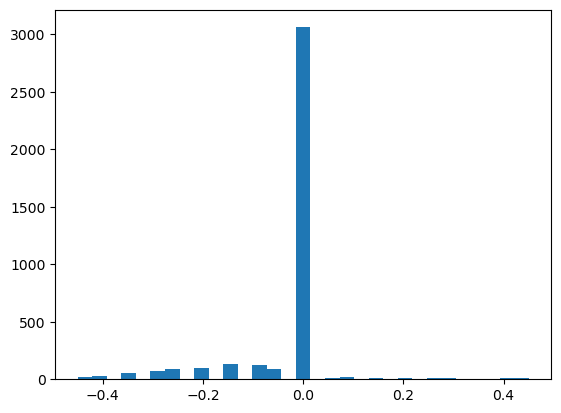

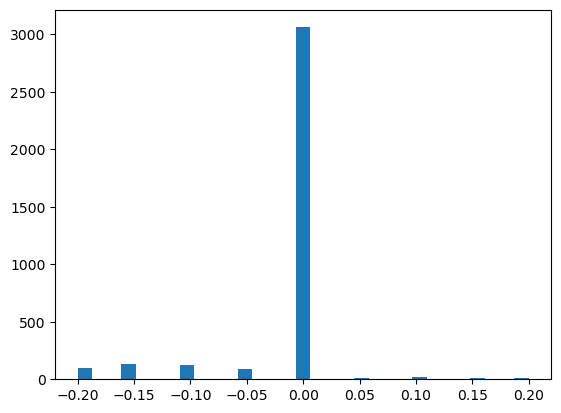

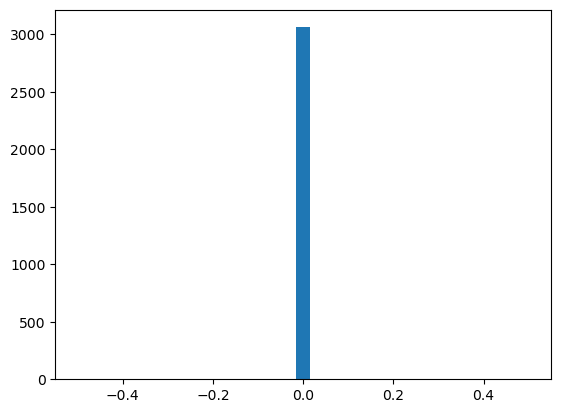

In [5]:
# Narrowing the dataset to find the straight angles threshold
testDf = df[df['steeringAngle'].abs() < 0.5]
plt.hist(testDf['steeringAngle'],bins = 31)
plt.show() # too many different angles other than 0.0
testDf = df[df['steeringAngle'].abs() < 0.25]
plt.hist(testDf['steeringAngle'],bins = 31)
plt.show() # better but still has other angles
testDf = df[df['steeringAngle'].abs() < 0.05]
plt.hist(testDf['steeringAngle'],bins = 31)
plt.show() # contains only 0.0 angles, will be used for balancing

In [6]:
# we will now train a base model on the ENTIRE dataset
# this will be our base model

# Splitting the dataset and using Nvidia's model architecture
# Split dataset
trainDf, valDf = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

In [7]:
# Model
ControlledAnglePredictor = Sequential([
    Input(shape=(66,200,3)),
    Conv2D(24, (5,5), strides=(2,2), activation='relu'),
    Conv2D(36, (5,5), strides=(2,2), activation='relu'),
    Conv2D(48, (5,5), strides=(2,2), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(50, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1)
])
ControlledAnglePredictor.compile(
    optimizer='adam', 
    loss='mean_squared_error',
    metrics=['accuracy']
)
ControlledAnglePredictor.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 31, 98, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 47, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 22, 48)      │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 3, 20, 64)      │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 1, 18, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,219 (985.23 KB)

 Trainable params: 252,219 (985.23 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Training
batchSize = 32
stepsPerEpoch = len(trainDf) // batchSize
validationSteps = len(valDf) // batchSize

earlyStop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

history = ControlledAnglePredictor.fit(
    generator(trainDf, batchSize),
    steps_per_epoch=stepsPerEpoch,
    validation_data=generator(valDf, batchSize),
    validation_steps=validationSteps,
    epochs=30,
    callbacks=[earlyStop]
)

ControlledAnglePredictor.save("ControlledAnglePredictor.keras")

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.2666 - loss: 0.0448 - val_accuracy: 0.2422 - val_loss: 0.0230
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.2717 - loss: 0.0185 - val_accuracy: 0.2995 - val_loss: 0.0158
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.2761 - loss: 0.0161 - val_accuracy: 0.2630 - val_loss: 0.0166
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.2714 - loss: 0.0153 - val_accuracy: 0.2747 - val_loss: 0.0160
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.2682 - loss: 0.0149 - val_accuracy: 0.3047 - val_loss: 0.0160
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.2768 - loss: 0.0149 - val_accuracy: 0.2539 - val_loss: 0.0157
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.2787 - loss: 0.0142 - val_accuracy: 0.2578 - val_loss: 0.0175
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.2679 - loss: 0.0149 - val_accuracy: 0.2721 - v

MSE: 0.008282184366007138
R² : 0.8530275433503419


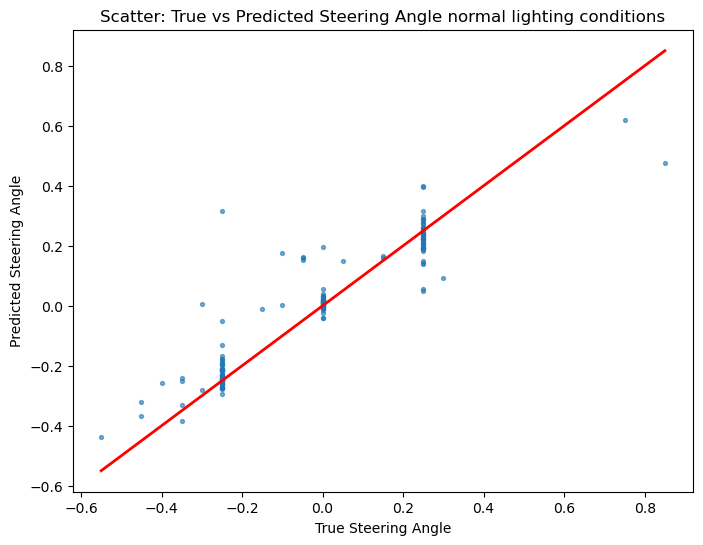

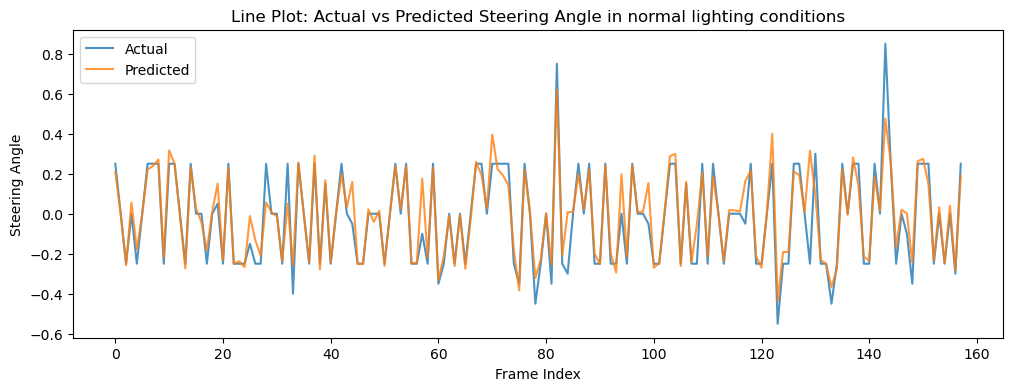

The total amount of turns sampled in this dataset is: 158
The amount of lane departures caused by this model is: 26
Turn error rate: 16.46%


In [9]:
# Testing the model
# Making predictions

#Testing dataset
xFullList = []
yFullList = [] # Start with an empty list
correction = 0.25

for i in range(len(valDf)):
    # Get the current row data
    row = valDf.iloc[i]
    choice = random.choice(['center', 'left', 'right'])
    xFullList.append(row[choice])
    # Calculate corrected angle
    angle = row['steeringAngle']
    if choice == 'left':
        angle += correction
    elif choice == 'right':
        angle -= correction
        
    yFullList.append(angle)
# Convert both to numpy array
xFull = np.array(xFullList)
yFull = np.array(yFullList)

unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2, shuffle=False)

yPred = []
for path in xValReal:
    img = loadImage(path)
    prediction = ControlledAnglePredictor.predict(np.expand_dims(img, 0), verbose=0)[0][0]
    yPred.append(prediction)

yPred = np.array(yPred)

# Metrics/visualisation

print("MSE:", mean_squared_error(yValReal, yPred))
print("R² :", r2_score(yValReal, yPred))

# Scatter plot of accuracy
plt.figure(figsize=(8,6))
plt.scatter(yValReal, yPred, s=8, alpha=0.6)
plt.plot([yValReal.min(), yValReal.max()],
         [yValReal.min(), yValReal.max()],
         color='red', linewidth=2)
plt.xlabel("True Steering Angle")
plt.ylabel("Predicted Steering Angle")
plt.title("Scatter: True vs Predicted Steering Angle normal lighting conditions")
plt.show()

# Line plot of accuracy
plt.figure(figsize=(12,4))
plt.plot(yValReal, label='Actual', alpha=0.8)
plt.plot(yPred, label='Predicted', alpha=0.8)
plt.xlabel("Frame Index")
plt.ylabel("Steering Angle")
plt.title("Line Plot: Actual vs Predicted Steering Angle in normal lighting conditions")
plt.legend()
plt.show()

dispTurnError(yValReal,yPred)

MSE: 0.01229701256656985
R² : 0.7843511532602447


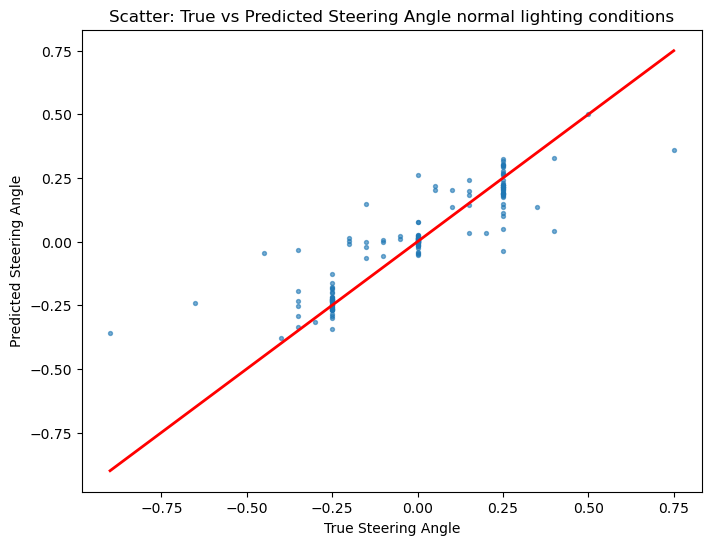

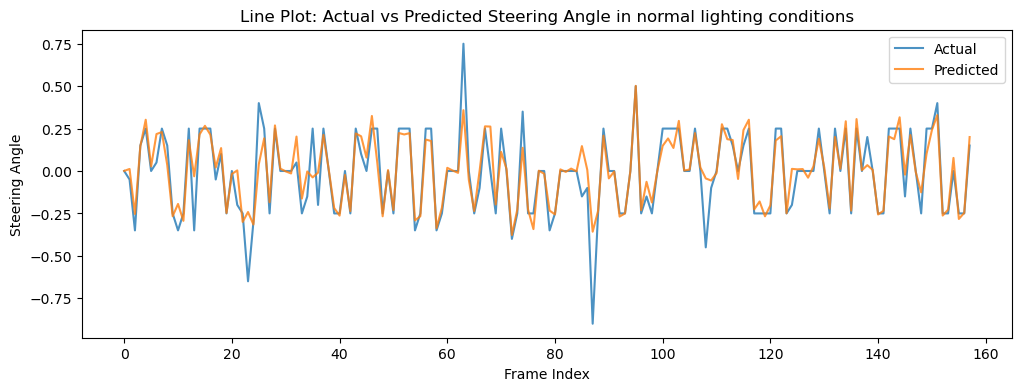

The total amount of turns sampled in this dataset is: 158
The amount of lane departures caused by this model is: 31
Turn error rate: 19.62%


In [10]:
#Creating a second test split to show that the model is not overfitted to the original train-test split
trainDf, valDf = train_test_split(df, test_size=0.2, random_state=923, shuffle=True)

# Testing the model
# Making predictions

#Testing dataset
xFullList = []
yFullList = [] # Start with an empty list
correction = 0.25

for i in range(len(valDf)):
    # Get the current row data
    row = valDf.iloc[i]
    choice = random.choice(['center', 'left', 'right'])
    xFullList.append(row[choice])
    # Calculate corrected angle
    angle = row['steeringAngle']
    if choice == 'left':
        angle += correction
    elif choice == 'right':
        angle -= correction
        
    yFullList.append(angle)
# Convert both to numpy array
xFull = np.array(xFullList)
yFull = np.array(yFullList)

unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2,shuffle=False)

yPred = []
for path in xValReal:
    img = loadImage(path)
    prediction = ControlledAnglePredictor.predict(np.expand_dims(img, 0), verbose=0)[0][0]
    yPred.append(prediction)

yPred = np.array(yPred)

# Metrics/visualisation

print("MSE:", mean_squared_error(yValReal, yPred))
print("R² :", r2_score(yValReal, yPred))

# Scatter plot of accuracy
plt.figure(figsize=(8,6))
plt.scatter(yValReal, yPred, s=8, alpha=0.6)
plt.plot([yValReal.min(), yValReal.max()],
         [yValReal.min(), yValReal.max()],
         color='red', linewidth=2)
plt.xlabel("True Steering Angle")
plt.ylabel("Predicted Steering Angle")
plt.title("Scatter: True vs Predicted Steering Angle normal lighting conditions")
plt.show()

# Line plot of accuracy
plt.figure(figsize=(12,4))
plt.plot(yValReal, label='Actual', alpha=0.8)
plt.plot(yPred, label='Predicted', alpha=0.8)
plt.xlabel("Frame Index")
plt.ylabel("Steering Angle")
plt.title("Line Plot: Actual vs Predicted Steering Angle in normal lighting conditions")
plt.legend()
plt.show()

dispTurnError(yValReal,yPred)

In [11]:
# we will now train a base model on the ENTIRE dataset with varying brightnesses using brightenImage(from 1.1 to 2.0)
# this will be our sesitivity analysis for brightness. We will pick the best performing model and brightness value to be our "bright"
# representative
# for the purpose of readability, we will encapsulate the bright code in a function that will be repeated for each brightness value,
# and we will only display the MSE, R2 and number of lane departures

def BrightnessTesting(value):
    # Splitting the dataset and using Nvidia's model architecture
    # Split dataset(keeping the random_state same)
    trainBrightDf, valBrightDf = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)
    
    # Model
    BrightAnglePredictor = Sequential([
        Input(shape=(66,200,3)),
        Conv2D(24, (5,5), strides=(2,2), activation='relu'),
        Conv2D(36, (5,5), strides=(2,2), activation='relu'),
        Conv2D(48, (5,5), strides=(2,2), activation='relu'),
        Conv2D(64, (3,3), activation='relu'),
        Conv2D(64, (3,3), activation='relu'),
        Flatten(),
        Dense(100, activation='relu'),
        Dense(50, activation='relu'),
        Dense(10, activation='relu'),
        Dense(1)
    ])
    
    BrightAnglePredictor.compile(
        optimizer='adam', 
        loss='mean_squared_error',
        metrics=['accuracy']
    )
    
    # BrightAnglePredictor.summary()
    
    # Training
    batchSize = 32
    stepsPerEpoch = len(trainDf) // batchSize
    validationSteps = len(valDf) // batchSize
    
    earlyStop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    
    history = BrightAnglePredictor.fit(
        generatorForBrightness(trainBrightDf, value, batchSize),
        steps_per_epoch=stepsPerEpoch,
        validation_data=generatorForBrightness(valBrightDf, value, batchSize),
        validation_steps=validationSteps,
        epochs=30,
        callbacks=[earlyStop]
    )
    
    BrightAnglePredictor.save("BrightAnglePredictor.keras")

    # Testing the model
    # Making predictions
    
    #Testing dataset
    xFullList = []
    yFullList = [] # Start with an empty list
    correction = 0.25
    
    for i in range(len(valBrightDf)):
        # Get the current row data
        row = valBrightDf.iloc[i]
        choice = random.choice(['center', 'left', 'right'])
        if random.random() > 0.5:
            xFullList.append(row[choice])
        else:
            # DO NOT store image, just store path
            xFullList.append(row[choice])
        # Calculate corrected angle
        angle = row['steeringAngle']
        if choice == 'left':
            angle += correction
        elif choice == 'right':
            angle -= correction
            
        yFullList.append(angle)
    # Convert both to numpy array
    xFull = np.array(xFullList)
    yFull = np.array(yFullList)
    
    unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2, shuffle=False)
    
    yPred = []
    for path in xValReal:
        img = loadImage(path)
        prediction = BrightAnglePredictor.predict(np.expand_dims(img, 0), verbose=0)[0][0]
        yPred.append(prediction)
    
    yPred = np.array(yPred)
    
    # Metrics/visualisation
    
    print("MSE:", mean_squared_error(yValReal, yPred))
    print("R² :", r2_score(yValReal, yPred))
    
    dispTurnError(yValReal,yPred)

# Brightness coefficient (between 1.1 and 1.9)
value = 1
for i in range(9):
    value +=0.1
    BrightnessTesting(value)
    print(value)

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.2675 - loss: 0.0555 - val_accuracy: 0.2552 - val_loss: 0.0342
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.2663 - loss: 0.0235 - val_accuracy: 0.2786 - val_loss: 0.0178
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.2701 - loss: 0.0173 - val_accuracy: 0.2773 - val_loss: 0.0180
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.2691 - loss: 0.0159 - val_accuracy: 0.2695 - val_loss: 0.0152
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.2710 - loss: 0.0159 - val_accuracy: 0.2617 - val_loss: 0.0152
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.2787 - loss: 0.0149 - val_accuracy: 0.2526 - val_loss: 0.0152
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.2656 - loss: 0.0146 - val_accuracy: 0.2682 - val_loss: 0.0146
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.2596 - loss: 0.0144 - val_accuracy: 0.2500 - v

In [12]:
# we will now train a base model on the ENTIRE dataset with varying brightnesses using brightenImage(from 0.9 to 0.1)
# this will be our sesitivity analysis for brightness. We will pick the best performing model and brightness value to be our "bright"
# representative
# for the purpose of readability, we will encapsulate the bright code in a function that will be repeated for each brightness value,
# and we will only display the MSE, R2 and number of lane departures

def DarknessTesting(value):
    # Splitting the dataset and using Nvidia's model architecture
    # Split dataset(keeping the random_state same)
    trainDarkDf, valDarkDf = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)
    
    # Model
    DarkAnglePredictor = Sequential([
        Input(shape=(66,200,3)),
        Conv2D(24, (5,5), strides=(2,2), activation='relu'),
        Conv2D(36, (5,5), strides=(2,2), activation='relu'),
        Conv2D(48, (5,5), strides=(2,2), activation='relu'),
        Conv2D(64, (3,3), activation='relu'),
        Conv2D(64, (3,3), activation='relu'),
        Flatten(),
        Dense(100, activation='relu'),
        Dense(50, activation='relu'),
        Dense(10, activation='relu'),
        Dense(1)
    ])
    
    DarkAnglePredictor.compile(
        optimizer='adam', 
        loss='mean_squared_error',
        metrics=['accuracy']
    )
    
    # DarkAnglePredictor.summary()
    
    # Training
    batchSize = 32
    stepsPerEpoch = len(trainDf) // batchSize
    validationSteps = len(valDf) // batchSize
    
    earlyStop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
    
    history = DarkAnglePredictor.fit(
        generatorForBrightness(trainDarkDf, value, batchSize),
        steps_per_epoch=stepsPerEpoch,
        validation_data=generatorForBrightness(valDarkDf, value, batchSize),
        validation_steps=validationSteps,
        epochs=30,
        callbacks=[earlyStop]
    )
    
    DarkAnglePredictor.save("DarkAnglePredictor.keras")

    # Testing the model
    # Making predictions
    
    #Testing dataset
    xFullList = []
    yFullList = [] # Start with an empty list
    correction = 0.25
    
    for i in range(len(valDarkDf)):
        # Get the current row data
        row = valDarkDf.iloc[i]
        choice = random.choice(['center', 'left', 'right'])
        if random.random() > 0.5:
            xFullList.append(row[choice])
        else:
            # DO NOT store image, just store path
            xFullList.append(row[choice])
        # Calculate corrected angle
        angle = row['steeringAngle']
        if choice == 'left':
            angle += correction
        elif choice == 'right':
            angle -= correction
            
        yFullList.append(angle)
    # Convert both to numpy array
    xFull = np.array(xFullList)
    yFull = np.array(yFullList)
    
    unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2, shuffle=False)
    
    yPred = []
    for path in xValReal:
        img = loadImage(path)
        prediction = DarkAnglePredictor.predict(np.expand_dims(img, 0), verbose=0)[0][0]
        yPred.append(prediction)
    
    yPred = np.array(yPred)
    
    # Metrics/visualisation
    
    print("MSE:", mean_squared_error(yValReal, yPred))
    print("R² :", r2_score(yValReal, yPred))
    
    dispTurnError(yValReal,yPred)

# Darkness coefficient (between 0.9 and 0.1)
value = 1
for i in range(9):
    value -=0.1
    DarknessTesting(value)
    print(value)

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.2637 - loss: 0.0440 - val_accuracy: 0.2617 - val_loss: 0.0210
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.2615 - loss: 0.0187 - val_accuracy: 0.2500 - val_loss: 0.0169
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.2726 - loss: 0.0165 - val_accuracy: 0.2773 - val_loss: 0.0160
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.2605 - loss: 0.0159 - val_accuracy: 0.2539 - val_loss: 0.0160
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.2707 - loss: 0.0153 - val_accuracy: 0.2878 - val_loss: 0.0166
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.2666 - loss: 0.0145 - val_accuracy: 0.2773 - val_loss: 0.0153
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.2682 - loss: 0.0148 - val_accuracy: 0.2578 - val_loss: 0.0162
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.2643 - loss: 0.0146 - val_accuracy: 0.2799 - v

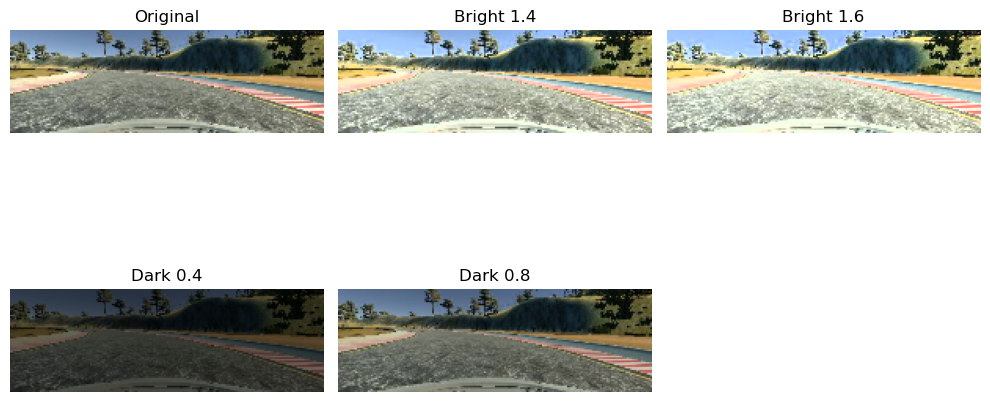

In [13]:
img = loadImage(df['center'][3])

plt.figure(figsize=(10,6))

plt.subplot(2,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(brightenImage(img, 1.4))
plt.title("Bright 1.4")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(brightenImage(img, 1.6))
plt.title("Bright 1.6")
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(darkenImage(img, 0.4))
plt.title("Dark 0.4")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(darkenImage(img, 0.8))
plt.title("Dark 0.8")
plt.axis('off')

plt.tight_layout()
#The highest performing bright value was tied between 1.4 and 1.6 so I decided to take 1.6 as 1.4 creates a relatively unnoticeable difference.
#The highest performing dark value was a close match between 0.4 and 0.8 so I decided to take 0.4 as 0.8 has a very slight difference from normal which is not what I am looking for

In [18]:
# we will now train a new model on bright, dark and normal images

# Splitting the dataset and using Nvidia's model architecture
# Split dataset
trainDf, valDf = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

# Model
AnglePredictorFullPotential = Sequential([
    Input(shape=(66,200,3)),
    Conv2D(24, (5,5), strides=(2,2), activation='relu'),
    Conv2D(36, (5,5), strides=(2,2), activation='relu'),
    Conv2D(48, (5,5), strides=(2,2), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    Conv2D(64, (3,3), activation='relu'),
    Flatten(),
    Dense(100, activation='relu'),
    Dense(50, activation='relu'),
    Dense(10, activation='relu'),
    Dense(1)
])
AnglePredictorFullPotential.compile(
    optimizer='adam', 
    loss='mean_squared_error',
    metrics=['accuracy']
)
AnglePredictorFullPotential.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_95 (Conv2D)              │ (None, 31, 98, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_96 (Conv2D)              │ (None, 14, 47, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 5, 22, 48)      │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_98 (Conv2D)              │ (None, 3, 20, 64)      │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_99 (Conv2D)              │ (None, 1, 18, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,219 (985.23 KB)

 Trainable params: 252,219 (985.23 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Training
batchSize = 32
stepsPerEpoch = len(trainDf) // batchSize
validationSteps = len(valDf) // batchSize

earlyStop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)

history = AnglePredictorFullPotential.fit(
    trainingGeneratorForBrightness(trainDf, batchSize),
    steps_per_epoch=stepsPerEpoch,
    validation_data=trainingGeneratorForBrightness(valDf, batchSize),
    validation_steps=validationSteps,
    epochs=30,
    callbacks=[earlyStop]
)

AnglePredictorFullPotential.save("AnglePredictorFullPotential.keras")

Epoch 1/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.2835 - loss: 0.0474 - val_accuracy: 0.2839 - val_loss: 0.0405
Epoch 2/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.2793 - loss: 0.0255 - val_accuracy: 0.2904 - val_loss: 0.0195
Epoch 3/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.2599 - loss: 0.0185 - val_accuracy: 0.2669 - val_loss: 0.0181
Epoch 4/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.2822 - loss: 0.0177 - val_accuracy: 0.2500 - val_loss: 0.0166
Epoch 5/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.2557 - loss: 0.0164 - val_accuracy: 0.2513 - val_loss: 0.0174
Epoch 6/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.2650 - loss: 0.0157 - val_accuracy: 0.3021 - val_loss: 0.0142
Epoch 7/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.2640 - loss: 0.0151 - val_accuracy: 0.2604 - val_loss: 0.0185
Epoch 8/30
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.2765 - loss: 0.0153 - val_accuracy: 0.2461 - v

MSE: 0.006957273036732933
R² : 0.8692916301745635


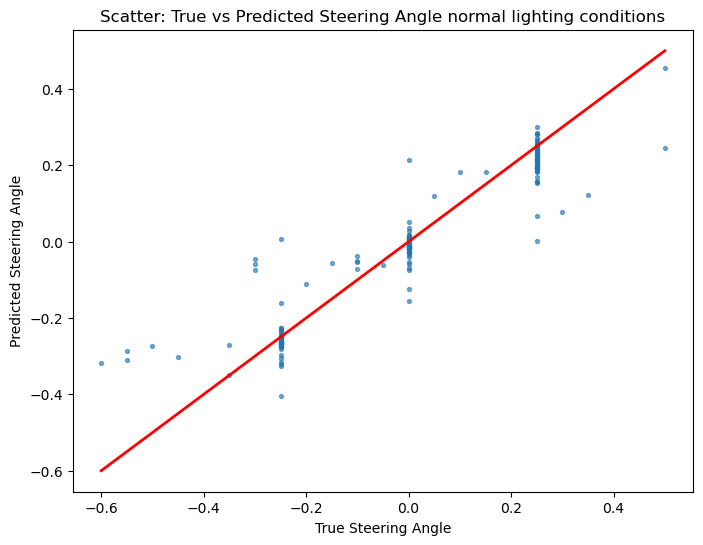

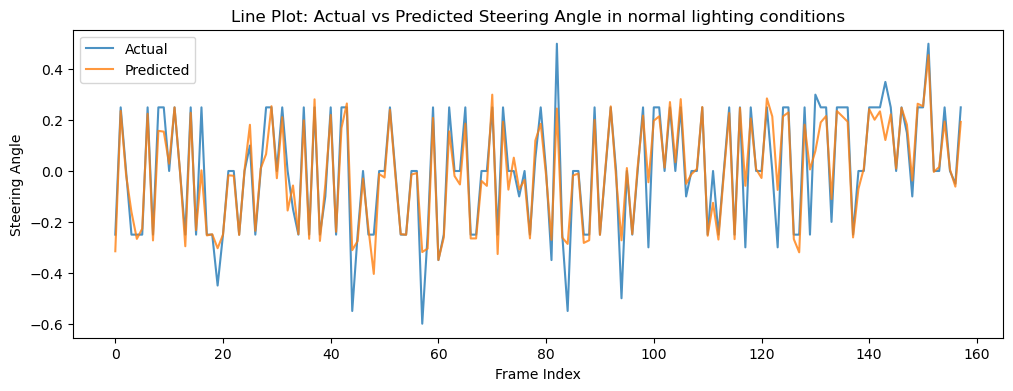

The total amount of turns sampled in this dataset is: 158
The amount of lane departures caused by this model is: 18
Turn error rate: 11.39%


In [20]:
# Testing the model
# Making predictions

#Testing dataset
xFullList = []
yFullList = [] # Start with an empty list
correction = 0.25

for i in range(len(valDf)):
    # Get the current row data
    row = valDf.iloc[i]
    choice = random.choice(['center', 'left', 'right'])
    xFullList.append(row[choice])
    # Calculate corrected angle
    angle = row['steeringAngle']
    if choice == 'left':
        angle += correction
    elif choice == 'right':
        angle -= correction
        
    yFullList.append(angle)
# Convert both to numpy array
xFull = np.array(xFullList)
yFull = np.array(yFullList)

unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2, shuffle=False)

yPred = []
for path in xValReal:
    img = loadImage(path)
    prediction = AnglePredictorFullPotential.predict(np.expand_dims(img, 0), verbose=0)[0][0]
    yPred.append(prediction)

yPred = np.array(yPred)

# Metrics/visualisation

print("MSE:", mean_squared_error(yValReal, yPred))
print("R² :", r2_score(yValReal, yPred))

# Scatter plot of accuracy
plt.figure(figsize=(8,6))
plt.scatter(yValReal, yPred, s=8, alpha=0.6)
plt.plot([yValReal.min(), yValReal.max()],
         [yValReal.min(), yValReal.max()],
         color='red', linewidth=2)
plt.xlabel("True Steering Angle")
plt.ylabel("Predicted Steering Angle")
plt.title("Scatter: True vs Predicted Steering Angle normal lighting conditions")
plt.show()

# Line plot of accuracy
plt.figure(figsize=(12,4))
plt.plot(yValReal, label='Actual', alpha=0.8)
plt.plot(yPred, label='Predicted', alpha=0.8)
plt.xlabel("Frame Index")
plt.ylabel("Steering Angle")
plt.title("Line Plot: Actual vs Predicted Steering Angle in normal lighting conditions")
plt.legend()
plt.show()

dispTurnError(yValReal,yPred)

MSE: 0.01137739102746684
R² : 0.8025244256389799


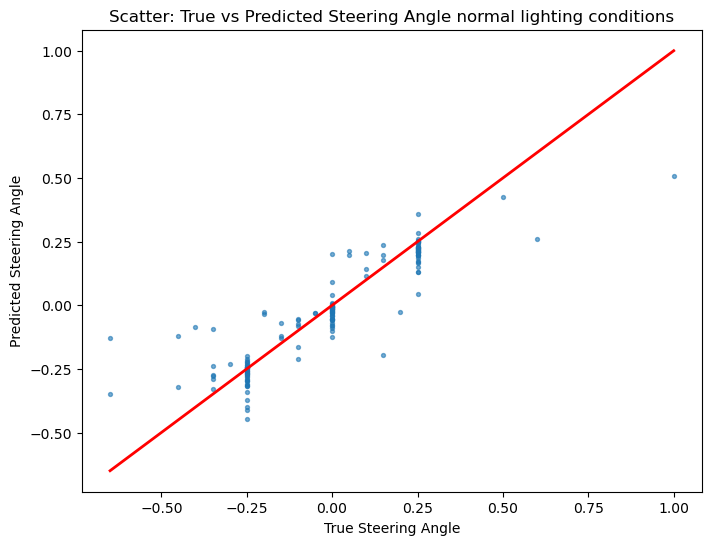

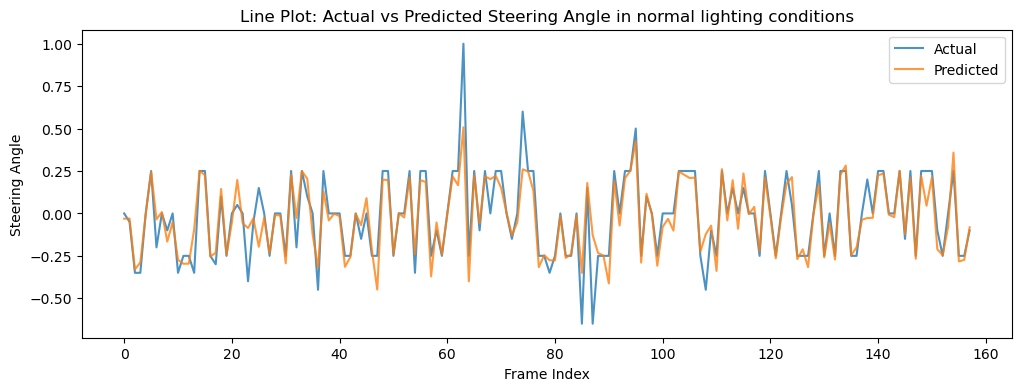

The total amount of turns sampled in this dataset is: 158
The amount of lane departures caused by this model is: 28
Turn error rate: 17.72%


In [21]:
#Creating a second test split to show that the model is not overfitted to the original train-test split
trainDf, valDf = train_test_split(df, test_size=0.2, random_state=923, shuffle=True)

# Testing the model
# Making predictions

#Testing dataset
xFullList = []
yFullList = [] # Start with an empty list
correction = 0.25

for i in range(len(valDf)):
    # Get the current row data
    row = valDf.iloc[i]
    choice = random.choice(['center', 'left', 'right'])
    xFullList.append(row[choice])
    # Calculate corrected angle
    angle = row['steeringAngle']
    if choice == 'left':
        angle += correction
    elif choice == 'right':
        angle -= correction
        
    yFullList.append(angle)
# Convert both to numpy array
xFull = np.array(xFullList)
yFull = np.array(yFullList)

unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2,shuffle=False)

yPred = []
for path in xValReal:
    img = loadImage(path)
    prediction = AnglePredictorFullPotential.predict(np.expand_dims(img, 0), verbose=0)[0][0]
    yPred.append(prediction)

yPred = np.array(yPred)

# Metrics/visualisation

print("MSE:", mean_squared_error(yValReal, yPred))
print("R² :", r2_score(yValReal, yPred))

# Scatter plot of accuracy
plt.figure(figsize=(8,6))
plt.scatter(yValReal, yPred, s=8, alpha=0.6)
plt.plot([yValReal.min(), yValReal.max()],
         [yValReal.min(), yValReal.max()],
         color='red', linewidth=2)
plt.xlabel("True Steering Angle")
plt.ylabel("Predicted Steering Angle")
plt.title("Scatter: True vs Predicted Steering Angle normal lighting conditions")
plt.show()

# Line plot of accuracy
plt.figure(figsize=(12,4))
plt.plot(yValReal, label='Actual', alpha=0.8)
plt.plot(yPred, label='Predicted', alpha=0.8)
plt.xlabel("Frame Index")
plt.ylabel("Steering Angle")
plt.title("Line Plot: Actual vs Predicted Steering Angle in normal lighting conditions")
plt.legend()
plt.show()

dispTurnError(yValReal,yPred)

MSE: 0.01169501404241394
R² : 0.81398022817252


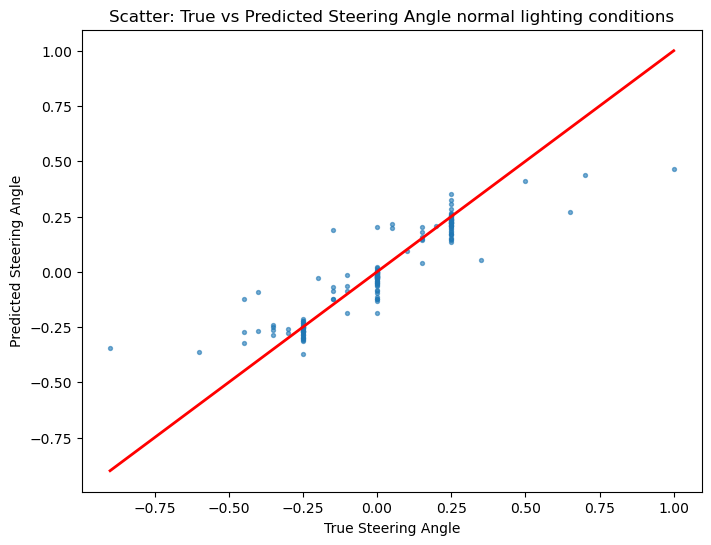

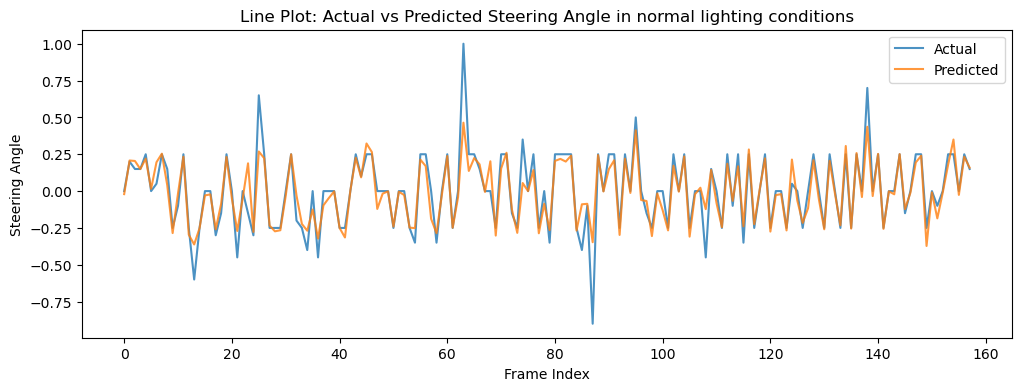

The total amount of turns sampled in this dataset is: 158
The amount of lane departures caused by this model is: 27
Turn error rate: 17.09%


In [22]:

#Creating a second test split to show that the model is not overfitted to the original train-test splittrainDf, valDf = train_test_split(df, test_size=0.2, random_state=923, shuffle=True)

# Testing the model
# Making predictions

#Testing dataset
xFullList = []
yFullList = [] # Start with an empty list
correction = 0.25

for i in range(len(valDf)):
    # Get the current row data
    row = valDf.iloc[i]
    choice = random.choice(['center', 'left', 'right'])
    xFullList.append(row[choice])
    # Calculate corrected angle
    angle = row['steeringAngle']
    if choice == 'left':
        angle += correction
    elif choice == 'right':
        angle -= correction
        
    yFullList.append(angle)
# Convert both to numpy array
xFull = np.array(xFullList)
yFull = np.array(yFullList)

unwantedVariable, xValReal, unwantedVariable, yValReal = train_test_split(xFull, yFull, test_size=0.2,shuffle=False)

yPred = []
for path in xValReal:
    img = loadImage(path)
    # Random lighting condition
    choice = random.choice(['normal', 'bright', 'dark'])
    if choice == 'normal':
        # normal
        pass
    elif choice == "bright":
        # bright
        factor = 1.6
        img = brightenImage(img, factor=factor)
    else:
        # dark
        factor = 0.4
        img = darkenImage(img, factor=factor)
    prediction = AnglePredictorFullPotential.predict(np.expand_dims(img, 0), verbose=0)[0][0]
    yPred.append(prediction)

yPred = np.array(yPred)

# Metrics/visualisation

print("MSE:", mean_squared_error(yValReal, yPred))
print("R² :", r2_score(yValReal, yPred))

# Scatter plot of accuracy
plt.figure(figsize=(8,6))
plt.scatter(yValReal, yPred, s=8, alpha=0.6)
plt.plot([yValReal.min(), yValReal.max()],
         [yValReal.min(), yValReal.max()],
         color='red', linewidth=2)
plt.xlabel("True Steering Angle")
plt.ylabel("Predicted Steering Angle")
plt.title("Scatter: True vs Predicted Steering Angle normal lighting conditions")
plt.show()

# Line plot of accuracy
plt.figure(figsize=(12,4))
plt.plot(yValReal, label='Actual', alpha=0.8)
plt.plot(yPred, label='Predicted', alpha=0.8)
plt.xlabel("Frame Index")
plt.ylabel("Steering Angle")
plt.title("Line Plot: Actual vs Predicted Steering Angle in normal lighting conditions")
plt.legend()
plt.show()

dispTurnError(yValReal,yPred)